<a href="https://colab.research.google.com/github/arpanghosal/CLion-cpp-projects/blob/master/Sat_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q tensorflow-datasets

In [3]:
import tensorflow_datasets as tfds
print(tfds.__version__, hasattr(tfds, "load"))

4.9.10 True


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__, "| tfds:", tfds.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0 | tfds: 4.9.10
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
%pip install -q datasets
from datasets import load_dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 9.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.2.0 which is incompatible.


In [4]:
ds = load_dataset("timm/eurosat-rgb")
class_names = ds["train"].features["label"].names
print(class_names)

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 55.3MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.4MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [5]:
def to_tf(split):
    x = np.stack([np.array(im.convert("RGB").resize((64, 64)))
                  for im in ds[split]["image"]]).astype("uint8")
    y = np.array(ds[split]["label"], dtype="int64")
    return tf.data.Dataset.from_tensor_slices((x, y))

train_ds, val_ds, test_ds = to_tf("train"), to_tf("validation"), to_tf("test")
print("Train/val/test sizes:", len(train_ds), len(val_ds), len(test_ds))

Train/val/test sizes: 16200 5400 5400


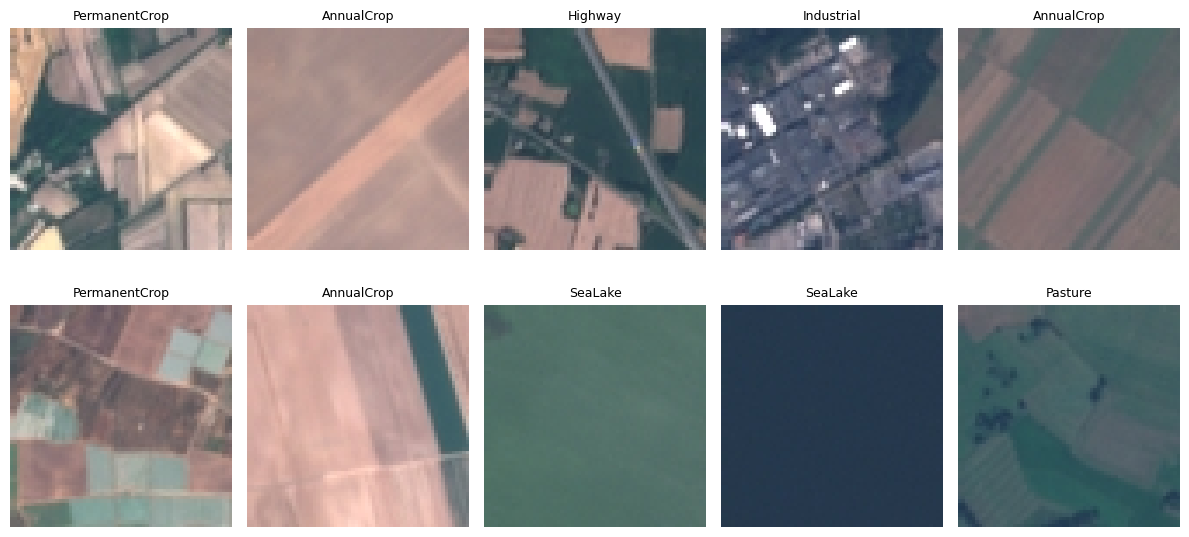

In [6]:
plt.figure(figsize=(12, 6))
for i, (img, label) in enumerate(train_ds.take(10)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.numpy())
    plt.title(class_names[label.numpy()], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
BATCH = 64
AUTOTUNE = tf.data.AUTOTUNE

def prep(img, label):
    return tf.cast(img, tf.float32) / 255.0, label

train = train_ds.map(prep, AUTOTUNE).shuffle(2000).batch(BATCH).prefetch(AUTOTUNE)
val   = val_ds.map(prep, AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
test  = test_ds.map(prep, AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)

In [8]:
def conv_block(filters):
    return [
        layers.Conv2D(filters, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
    ]

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.RandomFlip("horizontal_and_vertical"),   # augmentation, training only
    layers.RandomRotation(0.1),

    *conv_block(32),
    *conv_block(64),
    *conv_block(128),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.6375 - loss: 1.0285 - val_accuracy: 0.1381 - val_loss: 3.7416
Epoch 2/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7438 - loss: 0.7192 - val_accuracy: 0.4798 - val_loss: 1.5917
Epoch 3/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7793 - loss: 0.6173 - val_accuracy: 0.5817 - val_loss: 1.2075
Epoch 4/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7967 - loss: 0.5707 - val_accuracy: 0.3270 - val_loss: 2.5594
Epoch 5/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8148 - loss: 0.5250 - val_accuracy: 0.6511 - val_loss: 1.4801
Epoch 6/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8310 - loss: 0.4794 - val_accuracy: 0.5217 - val_loss: 3.3368
Epoch 7/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8475 - loss: 0.4412 - val_accuracy: 0.6667 - val_loss: 0.9552
Epoch 8/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.8587 - loss: 0.4114 - val_acc

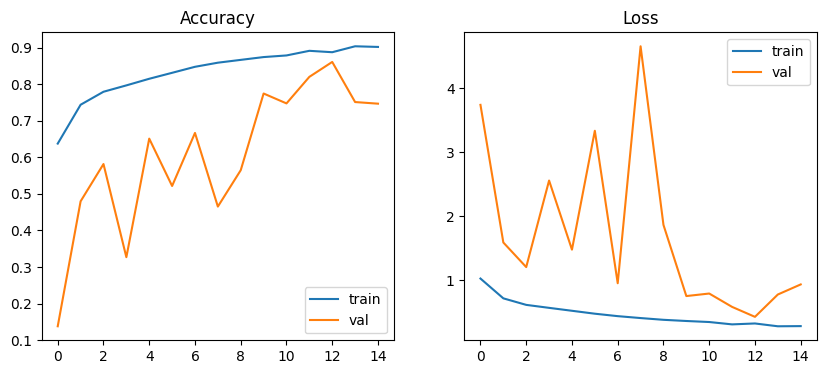

In [9]:
history = model.fit(train, validation_data=val, epochs=15)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()
plt.show()

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7506 - loss: 0.9010
Test accuracy: 0.751

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
                      precision    recall  f1-score   support

          AnnualCrop       0.84      0.47      0.60       596
              Forest       0.59      0.99      0.74       608
HerbaceousVegetation       0.58      0.94      0.72       573
             Highway       0.79      0.88      0.84       496
          Industrial       0.98      0.84      0.90       501
             Pasture       0.97      0.53      0.69       396
       PermanentCrop       0.70      0.62      0.66       538
         Residential       0.83      0.99      0.91       554
               River       0.80      0.81      0.80       529
             SeaLake       1.00      0.40      0.58       609

            accuracy                           0.75      5400
           macro avg       0.81      0.75      0.74      5400
        weighted avg       0.80      0.75      0.74     

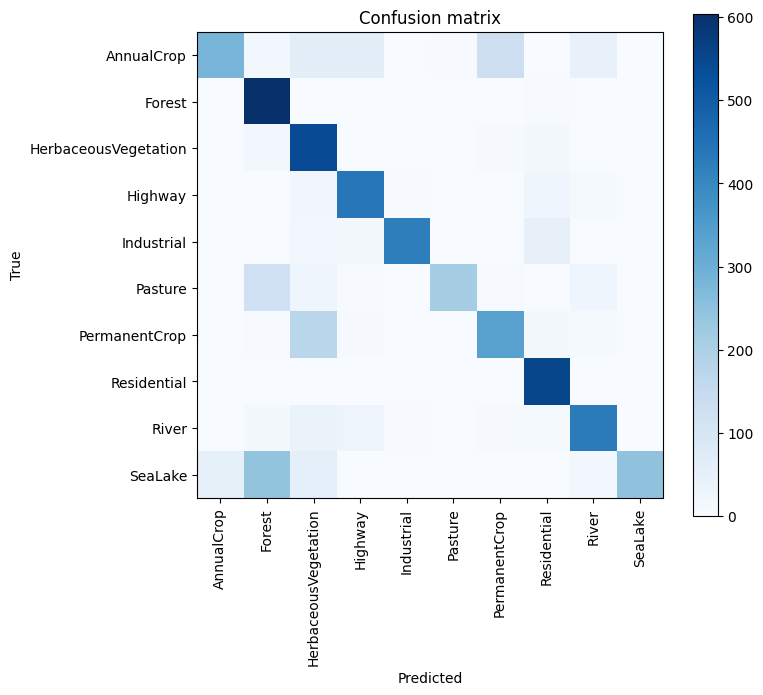

In [10]:
test_loss, test_acc = model.evaluate(test)
print(f"Test accuracy: {test_acc:.3f}\n")

y_true = np.concatenate([y.numpy() for _, y in test])
y_pred = np.argmax(model.predict(test), axis=1)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

Saving IMG_2903.png to IMG_2903.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step


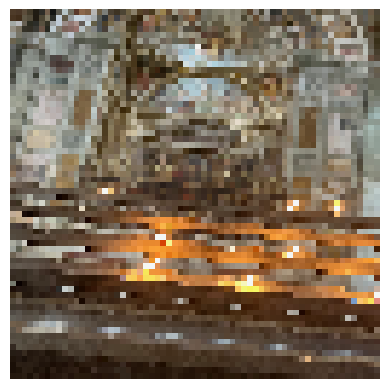

HerbaceousVegetation   64.2%
Highway                22.1%
Industrial             6.1%


In [11]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

def classify(path):
    img = load_img(path, target_size=(64, 64))
    x = img_to_array(img)[None] / 255.0
    p = model.predict(x)[0]
    plt.imshow(img); plt.axis("off"); plt.show()
    for i in np.argsort(p)[::-1][:3]:
        print(f"{class_names[i]:<22} {p[i]:.1%}")

uploaded = files.upload()          # pick an image from your computer
classify(next(iter(uploaded)))

Saving Screenshot 2026-09-24 at 15.07.05.png to Screenshot 2026-09-24 at 15.07.05.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


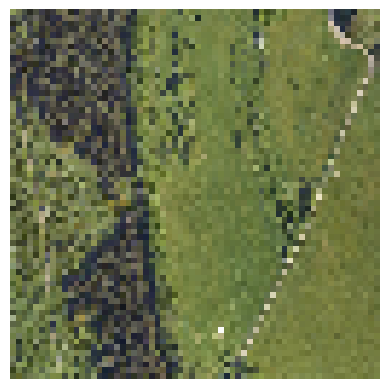

AnnualCrop             57.2%
Forest                 27.3%
PermanentCrop          14.0%


In [12]:
def classify(path):
    img = load_img(path, target_size=(64, 64))
    x = img_to_array(img)[None] / 255.0
    p = model.predict(x)[0]
    plt.imshow(img); plt.axis("off"); plt.show()
    for i in np.argsort(p)[::-1][:3]:
        print(f"{class_names[i]:<22} {p[i]:.1%}")

uploaded = files.upload()          # pick an image from your computer
classify(next(iter(uploaded)))